## Data


In [24]:
from poe import PortfolioOptimizationEnv
from utils import Utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from stockstats import wrap

# For not having unwanted errors
plt.rcParams["font.family"] = "DejaVu Sans"

In [25]:
df = pd.read_csv('./data/features_panel.csv')
df.info()
df = wrap(df)

<class 'pandas.DataFrame'>
RangeIndex: 62725 entries, 0 to 62724
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              62725 non-null  str    
 1   tic               62725 non-null  str    
 2   close             62725 non-null  float64
 3   volume            62725 non-null  float64
 4   rsi_6             62725 non-null  float64
 5   stochrsi_3        62725 non-null  float64
 6   volatility        62725 non-null  float64
 7   macd_stad         62725 non-null  float64
 8   macds_stad        62725 non-null  float64
 9   tema_stad         62725 non-null  float64
 10  pvo_stad          62725 non-null  float64
 11  pvos_stad         62725 non-null  float64
 12  pvoh_stad         62725 non-null  float64
 13  log-ret_stad      62725 non-null  float64
 14  adx_scale         62725 non-null  float64
 15  pdi_scale         62725 non-null  float64
 16  ndi_scale         62725 non-null  float64
 17  macd

In [26]:
features = df.copy()
features = features.reset_index()
features.info()


<class 'stockstats.StockDataFrame'>
RangeIndex: 62725 entries, 0 to 62724
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              62725 non-null  str    
 1   tic               62725 non-null  str    
 2   close             62725 non-null  float64
 3   volume            62725 non-null  float64
 4   rsi_6             62725 non-null  float64
 5   stochrsi_3        62725 non-null  float64
 6   volatility        62725 non-null  float64
 7   macd_stad         62725 non-null  float64
 8   macds_stad        62725 non-null  float64
 9   tema_stad         62725 non-null  float64
 10  pvo_stad          62725 non-null  float64
 11  pvos_stad         62725 non-null  float64
 12  pvoh_stad         62725 non-null  float64
 13  log-ret_stad      62725 non-null  float64
 14  adx_scale         62725 non-null  float64
 15  pdi_scale         62725 non-null  float64
 16  ndi_scale         62725 non-null  float64


In [27]:
TRAIN_WINDOW = 1000 # sessions
TEST_WINDOW = 200 # sessions

train, test = Utils.train_test_split(features, TRAIN_WINDOW, TEST_WINDOW)
test.reset_index(inplace=True, drop=True)
train.reset_index(inplace=True, drop=True)

In [28]:
train.dropna(inplace=True)
train.columns

Index(['date', 'tic', 'close', 'volume', 'rsi_6', 'stochrsi_3', 'volatility',
       'macd_stad', 'macds_stad', 'tema_stad', 'pvo_stad', 'pvos_stad',
       'pvoh_stad', 'log-ret_stad', 'adx_scale', 'pdi_scale', 'ndi_scale',
       'macd_signal', 'rsi_signal', 'adx_signal', 'cci_signal',
       'macd_signal_held', 'rsi_signal_held', 'adx_signal_held',
       'cci_signal_held'],
      dtype='str')

In [29]:
FEATURE_LIST = [
    "close",
    "volume",
    "rsi_6",
    "macd_stad",
    "macds_stad",
    "adx_scale",
    "pvo_stad",
    "tema_stad",
    "stochrsi_3",
    "log-ret_stad",
]


In [14]:
env = PortfolioOptimizationEnv(
    df = features,
    initial_amount = 10000,
    order_df = True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features = FEATURE_LIST,
)

Normalizing ['close', 'volume', 'rsi_6', 'macd_stad', 'macds_stad', 'adx_scale', 'pvo_stad', 'tema_stad', 'stochrsi_3', 'log-ret_stad'] by previous time...


## Equal-weight portfolio


In [30]:
# Equal Weight Portfolio
def equal_weight_portfolio(env):
    n = env._stock_dim
    weights = np.zeros(n + 1, dtype=np.float32)
    weights[1:] = 1/n
    weights /= weights.sum()
    rewards = []

    while True:
        obs, reward, terminated, truncated, info = env.step(weights)
        rewards.append(reward)
        if terminated:
            break
    
    return rewards

In [ ]:
ew_train_env = PortfolioOptimizationEnv(
    df=train,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)


In [ ]:
equal_weight_portfolio_rewards = equal_weight_portfolio(ew_train_env)


Initial portfolio value:10000
Final portfolio value: 25767.05859375
Final accumulative portfolio value: 2.5767059326171875
Maximum DrawDown: -0.16936825100807784
Sharpe ratio: 1.8257276257480592


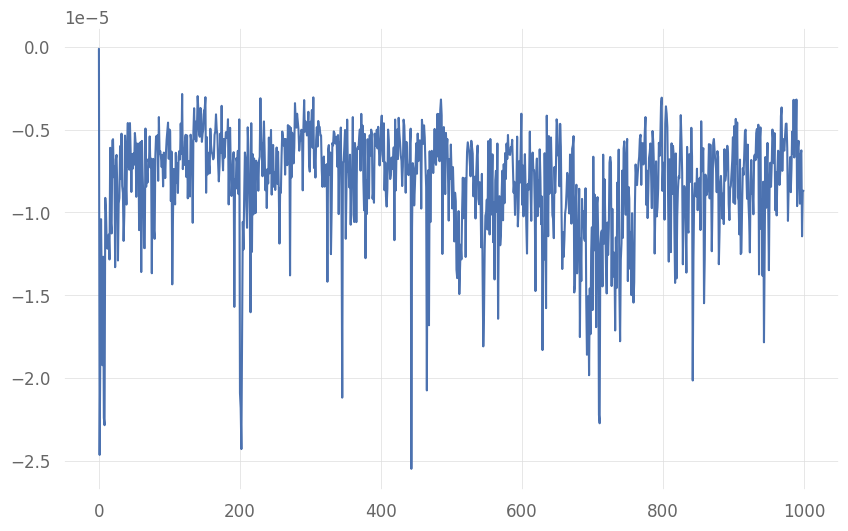

In [21]:
plt.plot(equal_weight_portfolio_rewards) # daily log returns

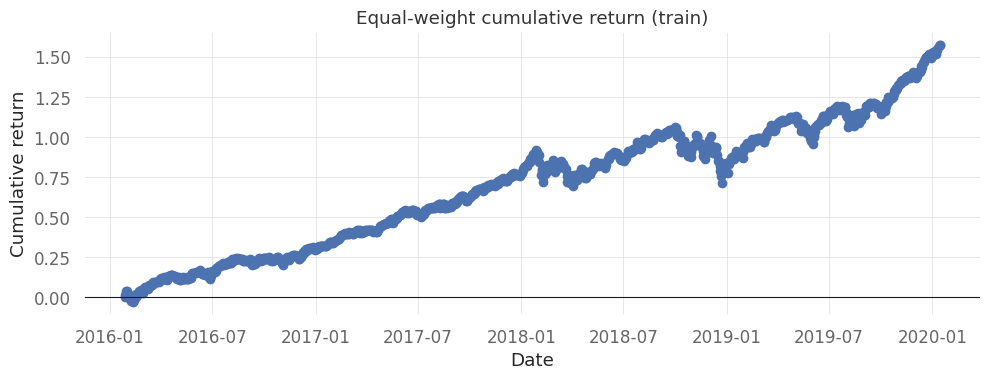

In [ ]:
values = np.asarray(ew_train_env._asset_memory["final"], dtype=float)
dates = pd.to_datetime(ew_train_env._date_memory)
cumulative = values / values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("Equal-weight cumulative return (train)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


Equal-weight cumulative return on the training window.


In [ ]:
ew_test_env = PortfolioOptimizationEnv(
    df=test,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)

rewards = equal_weight_portfolio(ew_test_env)


Initial portfolio value:10000
Final portfolio value: 11594.390625
Final accumulative portfolio value: 1.1594390869140625
Maximum DrawDown: -0.30240108210598393
Sharpe ratio: 0.6847720736464707


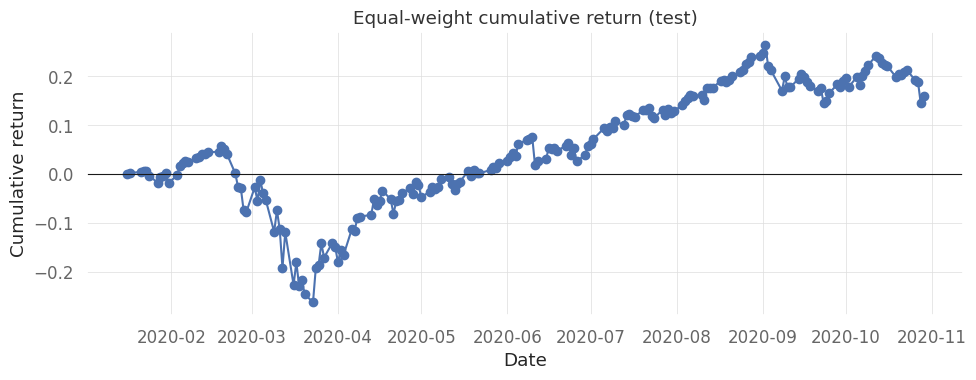

In [ ]:
ew_values = np.asarray(ew_test_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_test_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(ew_dates, ew_cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("Equal-weight cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


## PPO


In [ ]:
# Testing First RL Model
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

In [ ]:
train.describe()

,close,volume,rsi_6,stochrsi_3,volatility,macd_stad,macds_stad,tema_stad,pvo_stad,pvos_stad,...,pdi_scale,ndi_scale,macd_signal,rsi_signal,adx_signal,cci_signal,macd_signal_held,rsi_signal_held,adx_signal_held,cci_signal_held
count,25000.000000,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,93.926050,3.869177e+07,55.945722,53.533088,0.013745,-0.098224,-0.105564,-0.887212,-0.010091,-0.010139,...,0.419712,0.374152,0.020680,0.140520,0.153280,0.252240,0.048240,0.070800,0.247320,0.887320
std,75.775204,9.718960e+07,18.149024,45.913510,0.006812,0.429538,0.431328,0.312364,0.085444,0.067461,...,0.154800,0.159305,0.729845,0.735769,0.686122,0.461631,0.998295,0.996427,0.965831,0.441985
min,0.805635,4.538380e+05,0.000000,0.000000,0.000804,-2.679078,-2.465791,-2.001364,-0.468856,-0.421522,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,37.672989,4.901127e+06,42.992744,0.000000,0.009204,-0.304710,-0.319807,-1.094396,-0.065761,-0.053543,...,0.307325,0.257906,-1.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,1.000000
50%,62.364327,1.001521e+07,56.853783,64.564556,0.012030,-0.138383,-0.149253,-0.854347,-0.019589,-0.014242,...,0.410463,0.357602,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
75%,140.792879,2.699985e+07,69.610090,100.000000,0.016207,0.127781,0.121650,-0.647649,0.035144,0.028279,...,0.522742,0.475257,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,340.501123,2.828708e+09,100.000000,100.000000,0.075753,1.621795,1.554689,0.055397,0.616241,0.418533,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
ppo_train_env = PortfolioOptimizationEnv(
    df=train,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)


In [ ]:
obs, info = ppo_train_env.reset()
state = obs["state"] if isinstance(obs, dict) else obs

print(ppo_train_env.observation_space)
print("state", state.shape, state.dtype)
print("features", ppo_train_env._features)
print("date", info["end_time"])

frame = pd.DataFrame(
    state[:, :, -1],
    index=ppo_train_env._features,
    columns=list(ppo_train_env._tic_list),
).T
print(frame.describe().T)
print(frame.iloc[:5, :5])
print("nan", np.isnan(state).sum(), "inf", np.isinf(state).sum())


Dict('last_action': Box(0.0, 1.0, (26,), float32), 'state': Box(-inf, inf, (10, 25, 1), float32))
state (10, 25, 1) float32
features ['close', 'volume', 'rsi_6', 'macd_stad', 'macds_stad', 'adx_scale', 'pvo_stad', 'tema_stad', 'stochrsi_3', 'log-ret_stad']
date 2016-01-27 00:00:00
              count          mean           std           min           25%  \
close          25.0  5.992463e+01  4.575468e+01  9.059394e-01  2.685035e+01   
volume         25.0  5.426213e+07  1.282865e+08  1.827959e+06  7.718590e+06   
rsi_6          25.0  3.762302e+01  3.414593e+01  0.000000e+00  8.047707e+00   
macd_stad      25.0 -2.419251e-01  8.037486e-02 -3.625391e-01 -3.083820e-01   
macds_stad     25.0 -2.576643e-01  8.400446e-02 -3.913977e-01 -3.220493e-01   
adx_scale      25.0  8.054209e-01  1.599693e-01  4.950505e-01  7.241135e-01   
pvo_stad       25.0  4.905768e-03  9.064374e-03 -8.636008e-03 -4.321370e-04   
tema_stad      25.0 -1.294275e+00  3.259546e-01 -1.979006e+00 -1.544742e+00   
stochrs

In [ ]:
import optuna
from stable_baselines3.common.vec_env import VecNormalize

def rollout_value(model, df):
    env = PortfolioOptimizationEnv(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    vec_env, obs = env.get_sb_env()
    value = float(env._initial_amount)
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done[0]:
            break
        value = float(env._portfolio_value)
    return value

best_ppo = {"model": None, "score": -np.inf}

def objective_ppo(trial):
    n_steps = trial.suggest_categorical("n_steps", [512, 1024, 2048])
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])
    gamma = trial.suggest_float("gamma", 0.9, 0.999)
    trial_env = PortfolioOptimizationEnv(
        df=train,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    vec_env, _ = trial_env.get_sb_env()
    vec_env = VecNormalize(vec_env, norm_obs=False, norm_reward=True, clip_reward=10.0, gamma=gamma)
    model = PPO(
        "MultiInputPolicy",
        vec_env,
        verbose=0,
        seed=42,
        n_steps=n_steps,
        batch_size=batch_size,
        clip_range=trial.suggest_float("clip_range", 0.1, 0.3),
        gamma=gamma,
        tensorboard_log="./tb_ppo/",
        device="cpu",
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        policy_kwargs=dict(log_std_init=trial.suggest_float("log_std_init", -2.0, 0.0)),
    )
    model.learn(total_timesteps=10000, tb_log_name="ppo")
    score = rollout_value(model, train)
    if score > best_ppo["score"]:
        best_ppo["model"] = model
        best_ppo["score"] = score
    return score

study_ppo = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_ppo.optimize(objective_ppo, n_trials=10)
model_ppo = best_ppo["model"]
model_ppo.save("ppo_portfolio")
print(study_ppo.best_params, best_ppo["score"])


[I 2026-09-26 00:57:43,283] A new study created in memory with name: no-name-d2c7383a-9eda-4091-8d7b-56f8c73ef99c
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 23145.7265625
Final accumulative portfolio value: 2.31457257270813
Maximum DrawDown: -0.16239255296409005
Sharpe ratio: 1.6848496830413915
Initial portfolio value:10000
Final portfolio value: 23159.9296875
Final accumulative portfolio value: 2.315993070602417
Maximum DrawDown: -0.1640387478139559
Sharpe ratio: 1.6884277430216401
Initial portfolio value:10000
Final portfolio value: 23025.18359375
Final accumulative portfolio value: 2.302518367767334
Maximum DrawDown: -0.165351790205716
Sharpe ratio: 1.6751235710537586
Initial portfolio value:10000
Final portfolio value: 22993.5078125
Final accumulative portfolio value: 2.2993507385253906
Maximum DrawDown: -0.16596439493127135
Sharpe ratio: 1.6752455222337748
Initial portfolio value:10000
Final portfolio value: 22960.8671875
Final accumulative portfolio value: 2.2960867881774902
Maximum DrawDown: -0.16574979554790437
Sharpe ratio: 1.6718350212934419
Initial portfolio value:10000
Final 

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 24587.974609375
Final accumulative portfolio value: 2.4587974548339844
Maximum DrawDown: -0.16349675384442086
Sharpe ratio: 1.8033370325076228


[I 2026-09-26 01:00:46,642] Trial 0 finished with value: 24587.974609375 and parameters: {'n_steps': 1024, 'batch_size': 64, 'gamma': 0.9857514384317185, 'clip_range': 0.22022300234864176, 'learning_rate': 0.0002607024758370766, 'log_std_init': -1.958831011408395}. Best is trial 0 with value: 24587.974609375.
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


...

Initial portfolio value:10000
Final portfolio value: 18870.103515625
Final accumulative portfolio value: 1.8870103359222412
Maximum DrawDown: -0.16143994349103308
Sharpe ratio: 1.2824499969427665
Initial portfolio value:10000
Final portfolio value: 19157.435546875
Final accumulative portfolio value: 1.9157435894012451
Maximum DrawDown: -0.166676290369572
Sharpe ratio: 1.3156124507200946
Initial portfolio value:10000
Final portfolio value: 18669.15234375
Final accumulative portfolio value: 1.866915225982666
Maximum DrawDown: -0.1729262574228312
Sharpe ratio: 1.2590197965714702
Initial portfolio value:10000
Final portfolio value: 18617.205078125
Final accumulative portfolio value: 1.8617205619812012
Maximum DrawDown: -0.17483076388076946
Sharpe ratio: 1.262094740409151
Initial portfolio value:10000
Final portfolio value: 18544.279296875
Final accumulative portfolio value: 1.8544279336929321
Maximum DrawDown: -0.1757737733059388
Sharpe ratio: 1.2534500355664822
Initial portfolio value:100

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 24519.623046875
Final accumulative portfolio value: 2.4519622325897217
Maximum DrawDown: -0.16450693618217405
Sharpe ratio: 1.796389355653499


[I 2026-09-26 01:22:32,887] Trial 7 finished with value: 24519.623046875 and parameters: {'n_steps': 1024, 'batch_size': 64, 'gamma': 0.9307872498498506, 'clip_range': 0.16503666440534942, 'learning_rate': 0.0002878805718308924, 'log_std_init': -0.7248850572895738}. Best is trial 3 with value: 24917.6953125.
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 23122.71484375
Final accumulative portfolio value: 2.3122715950012207
Maximum DrawDown: -0.16232355134804055
Sharpe ratio: 1.6831885767807373
Initial portfolio value:10000
Final portfolio value: 23173.51171875
Final accumulative portfolio value: 2.3173511028289795
Maximum DrawDown: -0.16369360476707617
Sharpe ratio: 1.689957710229774
Initial portfolio value:10000
Final portfolio value: 23052.505859375
Final accumulative portfolio value: 2.305250644683838
Maximum DrawDown: -0.1650149320353268
Sharpe ratio: 1.6779833127839976
Initial portfolio value:10000
Final portfolio value: 22998.123046875
Final accumulative portfolio value: 2.2998123168945312
Maximum DrawDown: -0.16540585886531833
Sharpe ratio: 1.6755665869090128
Initial portfolio value:10000
Final portfolio value: 22936.470703125
Final accumulative portfolio value: 2.293647050857544
Maximum DrawDown: -0.16526654595872559
Sharpe ratio: 1.6701457857945579
Initial portfolio value:10

In [ ]:
ppo_test_env = PortfolioOptimizationEnv(
    df=test,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
env_test, obs = ppo_test_env.get_sb_env()

values, dates = (
    list(ppo_test_env._asset_memory["final"]),
    list(ppo_test_env._date_memory),
)
while True:
    action, _ = model_ppo.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ppo_test_env._asset_memory["final"])
    dates = list(ppo_test_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("PPO cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


In [ ]:
sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
recent = features[pd.to_datetime(features["date"]).isin(sessions[-500:])]

ppo_recent_env = PortfolioOptimizationEnv(
    df=recent,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
env_test, obs = ppo_recent_env.get_sb_env()

values, dates = (
    list(ppo_recent_env._asset_memory["final"]),
    list(ppo_recent_env._date_memory),
)
while True:
    action, _ = model_ppo.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ppo_recent_env._asset_memory["final"])
    dates = list(ppo_recent_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

ew_recent_env = PortfolioOptimizationEnv(
    df=recent,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
_ = equal_weight_portfolio(ew_recent_env)
ew_values = np.asarray(ew_recent_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_recent_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o", label="PPO")
plt.plot(ew_dates, ew_cumulative, marker="o", label="Equal weight")
plt.axhline(0, color="k", lw=0.8)
plt.title("Cumulative return (last 500 sessions)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.tight_layout()
plt.show()


## DDPG


In [ ]:
ddpg_train_env = PortfolioOptimizationEnv(
    df=train,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)

from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import VecNormalize
import optuna

n_actions = ddpg_train_env.action_space.shape[-1]
best_ddpg = {"model": None, "score": -np.inf}

def objective_ddpg(trial):
    gamma = trial.suggest_float("gamma", 0.95, 0.999)
    sigma = trial.suggest_float("sigma", 0.05, 0.2)
    action_noise = NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=sigma * np.ones(n_actions),
    )
    trial_env = PortfolioOptimizationEnv(
        df=train,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    vec_env, _ = trial_env.get_sb_env()
    vec_env = VecNormalize(vec_env, norm_obs=False, norm_reward=True, clip_reward=10.0, gamma=gamma)
    model = DDPG(
        "MultiInputPolicy",
        vec_env,
        verbose=0,
        seed=42,
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        buffer_size=100_000,
        learning_starts=trial.suggest_categorical("learning_starts", [500, 1000, 2000]),
        tau=trial.suggest_float("tau", 1e-3, 1e-2, log=True),
        gamma=gamma,
        train_freq=1,
        gradient_steps=1,
        batch_size=trial.suggest_categorical("batch_size", [64, 128, 256]),
        tensorboard_log="./tb_ddpg/",
        device="cuda",
        action_noise=action_noise,
    )
    model.learn(total_timesteps=25000, tb_log_name="ddpg")
    score = rollout_value(model, train)
    if score > best_ddpg["score"]:
        best_ddpg["model"] = model
        best_ddpg["score"] = score
    return score

study_ddpg = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_ddpg.optimize(objective_ddpg, n_trials=10)
model_ddpg = best_ddpg["model"]
model_ddpg.save("ddpg_portfolio")
print(study_ddpg.best_params, best_ddpg["score"])


In [ ]:
def test_function(model, df, title):
    env = PortfolioOptimizationEnv(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        normalize_df=None,  # type: ignore[arg-type]
        return_last_action=True,
    )

    env_test, obs = env.get_sb_env()
    values, dates = (
        list(env._asset_memory["final"]),
        list(env._date_memory),
    )
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = env_test.step(action)
        if done[0]:
            break
        values = list(env._asset_memory["final"])
        dates = list(env._date_memory)
    
    values = np.asarray(values, dtype=float)
    dates = pd.to_datetime(dates)
    cumulative = values / values[0] - 1

    plt.figure(figsize=(10, 4))
    plt.plot(dates, cumulative, marker="o")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative return")
    plt.tight_layout()
    plt.show()

In [ ]:
ddpg_test_env = PortfolioOptimizationEnv(
    df=test,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
env_test, obs = ddpg_test_env.get_sb_env()

values, dates = (
    list(ddpg_test_env._asset_memory["final"]),
    list(ddpg_test_env._date_memory),
)
while True:
    action, _ = model_ddpg.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ddpg_test_env._asset_memory["final"])
    dates = list(ddpg_test_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("DDPG cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


In [ ]:
sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
recent = features[pd.to_datetime(features["date"]).isin(sessions[-500:])]

ddpg_recent_env = PortfolioOptimizationEnv(
    df=recent,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
env_test, obs = ddpg_recent_env.get_sb_env()

values, dates = (
    list(ddpg_recent_env._asset_memory["final"]),
    list(ddpg_recent_env._date_memory),
)
while True:
    action, _ = model_ddpg.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ddpg_recent_env._asset_memory["final"])
    dates = list(ddpg_recent_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

ew_recent_env = PortfolioOptimizationEnv(
    df=recent,
    initial_amount=10000,
    order_df=True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features=FEATURE_LIST,
    return_last_action=True,
    normalize_df=None,  # type: ignore[arg-type]
)
_ = equal_weight_portfolio(ew_recent_env)
ew_values = np.asarray(ew_recent_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_recent_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o", label="DDPG")
plt.plot(ew_dates, ew_cumulative, marker="o", label="Equal weight")
plt.axhline(0, color="k", lw=0.8)
plt.title("Cumulative return (last 500 sessions)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.tight_layout()
plt.show()


## Strategy comparison


In [ ]:
def portfolio_curve(env):
    values = np.asarray(env._asset_memory["final"], dtype=float)
    dates = pd.to_datetime(env._date_memory)
    return dates, values / values[0] - 1

def equal_weight_curve(df):
    env = PortfolioOptimizationEnv(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    equal_weight_portfolio(env)
    return portfolio_curve(env)

def policy_curve(model, df):
    env = PortfolioOptimizationEnv(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,  # type: ignore[arg-type]
    )
    vec_env, obs = env.get_sb_env()
    values = list(env._asset_memory["final"])
    dates = list(env._date_memory)
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done[0]:
            break
        values = list(env._asset_memory["final"])
        dates = list(env._date_memory)
    values = np.asarray(values, dtype=float)
    return pd.to_datetime(dates), values / values[0] - 1

sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
recent = features[pd.to_datetime(features["date"]).isin(sessions[-500:])].copy()

windows = (
    ("Test window", test),
    ("Last 500 sessions", recent),
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (title, df) in zip(axes, windows):
    span = pd.to_datetime(df["date"])
    curves = (
        ("Equal weight",) + equal_weight_curve(df),
        ("PPO",) + policy_curve(model_ppo, df),
        ("DDPG",) + policy_curve(model_ddpg, df),
    )
    for label, dates, cumulative in curves:
        ax.plot(dates, cumulative, marker="o", label=label)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{title}\n{span.min():%Y-%m-%d} to {span.max():%Y-%m-%d}")
    ax.set_xlabel("Date")
    ax.legend()
axes[0].set_ylabel("Cumulative return")
fig.tight_layout()
plt.show()
